<a href="https://colab.research.google.com/github/adampinks89-svg/kk/blob/jules-15129327453012808240-4494c8c9/Wan2.1_T2I_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content
!git clone https://github.com/comfyanonymous/ComfyUI /content/ComfyUI
!git clone https://github.com/city96/ComfyUI-GGUF /content/ComfyUI/custom_nodes/ComfyUI-GGUF
!pip install torchsde gguf

!apt install aria2 -qqy
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/city96/Wan2.1-T2V-14B-gguf/resolve/main/wan2.1-t2v-14b-Q3_K_S.gguf -d /content/ComfyUI/models/unet -o wan2.1-t2v-14b-Q3_K_M.gguf
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/city96/umt5-xxl-encoder-gguf/resolve/main/umt5-xxl-encoder-Q3_K_S.gguf -d /content/ComfyUI/models/clip -o umt5-xxl-encoder-Q3_K_M.gguf
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/Comfy-Org/Wan_2.1_ComfyUI_repackaged/resolve/main/split_files/vae/wan_2.1_vae.safetensors -d /content/ComfyUI/models/vae -o/wan_2.1_vae.safetensors
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/vrgamedevgirl84/Wan14BT2VFusioniX/resolve/main/FusionX_LoRa/Wan2.1_T2V_14B_FusionX_LoRA.safetensors -d /content/ComfyUI/models/loras/FusionX -o Wan2.1_T2V_14B_FusionX_LoRA.safetensors

/content
Cloning into '/content/ComfyUI'...
remote: Enumerating objects: 49543, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 49543 (delta 20), reused 9 (delta 9), pack-reused 49508 (from 3)
Receiving objects: 100% (49543/49543), 89.33 MiB | 12.13 MiB/s, done.
Resolving deltas: 100% (33731/33731), done.
Cloning into '/content/ComfyUI/custom_nodes/ComfyUI-GGUF'...
remote: Enumerating objects: 814, done.
remote: Counting objects: 100% (546/546), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 814 (delta 492), reused 343 (delta 343), pack-reused 268 (from 1)
Receiving objects: 100% (814/814), 189.51 KiB | 3.79 MiB/s, done.
Resolving deltas: 100% (543/543), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 15.1 MB/s eta 0:00:00
The following additional packages will be installed:
  libaria2-0 libcares2
The f

In [8]:
%pip install comfy_aimdo comfy_kitchen av
%cd /content/ComfyUI

import torch
import random, time
import asyncio
from PIL import Image
import numpy as np

from nodes import NODE_CLASS_MAPPINGS, load_custom_node
from comfy_extras import nodes_hunyuan, nodes_model_advanced

# Ponieważ load_custom_node jest funkcją asynchroniczną, musimy jej użyć z await
await load_custom_node("/content/ComfyUI/custom_nodes/ComfyUI-GGUF")

UnetLoaderGGUF = NODE_CLASS_MAPPINGS["UnetLoaderGGUF"]()
CLIPLoaderGGUF = NODE_CLASS_MAPPINGS["CLIPLoaderGGUF"]()
LoraLoaderModelOnly = NODE_CLASS_MAPPINGS["LoraLoaderModelOnly"]()
VAELoader = NODE_CLASS_MAPPINGS["VAELoader"]()

CLIPTextEncode = NODE_CLASS_MAPPINGS["CLIPTextEncode"]()
EmptyHunyuanLatentVideo = nodes_hunyuan.EmptyHunyuanLatentVideo()

KSampler = NODE_CLASS_MAPPINGS["KSampler"]()
ModelSamplingSD3 = nodes_model_advanced.ModelSamplingSD3()
VAEDecode = NODE_CLASS_MAPPINGS["VAEDecode"]()

with torch.inference_mode():
    unet = UnetLoaderGGUF.load_unet("wan2.1-t2v-14b-Q3_K_M.gguf")[0]
    clip = CLIPLoaderGGUF.load_clip("umt5-xxl-encoder-Q3_K_M.gguf", "wan")[0]
    lora = LoraLoaderModelOnly.load_lora_model_only(unet, "FusionX/Wan2.1_T2V_14B_FusionX_LoRA.safetensors", 1.0)[0]
    vae = VAELoader.load_vae("wan_2.1_vae.safetensors")[0]

/content/ComfyUI


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_1654/4187896260.py:33: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  image = Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0]).save(f"/content/test.png")
/tmp/ipykernel_1654/4187896260.py:35: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0])


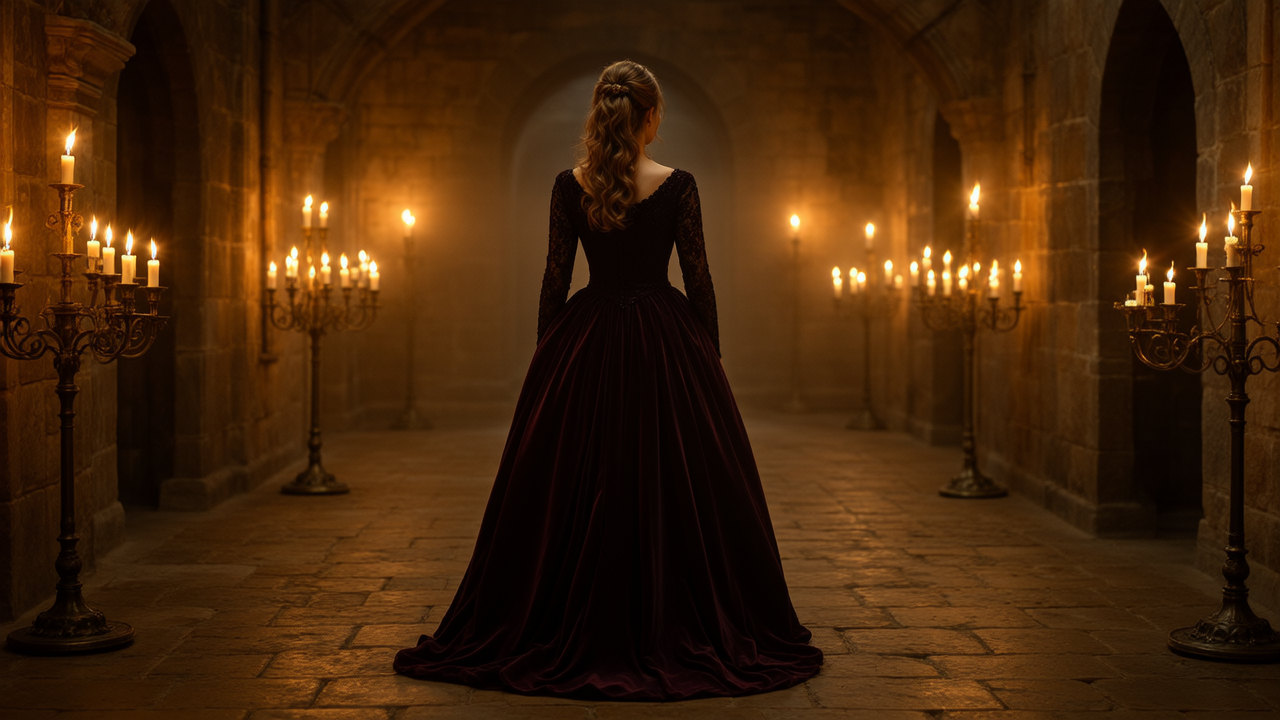

In [13]:
import comfy.ldm.flux.math
import comfy.ldm.wan.model
import comfy.quant_ops

# Wyłączamy flagę dostępności biblioteki kitchen
comfy.quant_ops.AVAILABLE = False

# Nadpisujemy funkcję bezpośrednio w modułach, które już ją zaimportowały
comfy.ldm.flux.math.apply_rope1 = comfy.ldm.flux.math._apply_rope1
comfy.ldm.wan.model.apply_rope1 = comfy.ldm.flux.math._apply_rope1

with torch.inference_mode():
    seed = 0
    steps = 10
    cfg = 1.0
    sampler_name = "euler"
    scheduler = "beta"
    width = 1280
    height = 720
    length = 1
    positive_prompt = "In a dim, candlelit medieval hall, a queen walks slowly along a corridor lined with flickering torches. The camera tracks her from behind in a long, steady tracking shot, capturing the heavy drape of her velvet gown and the echo of her footsteps. Shadows dance across the stone walls, and dust swirls in the warm volumetric light. The mood is regal, tense, and quietly suspenseful."
    negative_prompt = "色调艳丽，过曝，静态，细节模糊不清，字幕，风格，作品，画作，画面，静止，整体发灰，最差质量，低质量，JPEG压缩残留，丑陋的，残缺 of minor details, ugly, deformed"
    positive = CLIPTextEncode.encode(clip, positive_prompt)[0]
    negative = CLIPTextEncode.encode(clip, negative_prompt)[0]
    model = ModelSamplingSD3.patch(lora, 1.0)[0]
    latent_image = EmptyHunyuanLatentVideo.generate(width, height, length)[0]
    if seed == 0:
        random.seed(int(time.time()))
        seed = random.randint(0, 18446744073709551615)
    samples = KSampler.sample(model, seed, steps, cfg, sampler_name, scheduler, positive, negative, latent_image)[0]

    decoded = VAEDecode.decode(vae, samples)[0].detach()
    image = Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0]).save(f"/content/test.png")

Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0])

### Uruchomienie ComfyUI z dostępem przez przeglądarkę (Interfejs Graficzny)

Poniższa komórka pobierze Twój publiczny adres IP (który będzie potrzebny jako hasło/password dla usługi `localtunnel`), zainstaluje narzędzie tunelujące i uruchomi serwer ComfyUI w tle.

**Instrukcja:**
1. Uruchom poniższą komórkę.
2. Skopiuj adres IP wyświetlony w pierwszej linii (np. `34.123.45.67`).
3. Kliknij w link zakończony końcówką `.loca.lt`, który pojawi się poniżej.
4. Na otwartej stronie wklej skopiowany adres IP w pole "Tunnel Password" i kliknij Submit.

In [14]:
# 1. Pobranie zewnętrznego IP (potrzebne jako hasło do localtunnel)
print("Twoje hasło do tunelu (IP Colab):")
!curl ipv4.icanhazip.com
print("\nUruchamianie tunelu i serwera ComfyUI...")

# 2. Instalacja localtunnel
!npm install -g localtunnel

# 3. Uruchomienie serwera ComfyUI oraz tunelu równolegle
import subprocess
import threading
import time

def run_comfyui():
    # Uruchamiamy serwer na porcie 8188
    subprocess.run(["python", "main.py", "--port", "8188", "--dont-upcast-attention"], cwd="/content/ComfyUI")

def run_tunnel():
    # Dajemy serwerowi 5 sekund na start, po czym odpalamy tunel
    time.sleep(5)
    subprocess.run(["npx", "localtunnel", "--port", "8188"])

# Uruchomienie procesów w wątkach pobocznych, aby nie blokować całkowicie notebooka na amen
threading.Thread(target=run_comfyui, daemon=True).start()
threading.Thread(target=run_tunnel).start()

Twoje hasło do tunelu (IP Colab):
34.126.83.41

Uruchamianie tunelu i serwera ComfyUI...
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 2s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [15]:
# Pomocnicze sprawdzenie aktywnego adresu URL wygenerowanego przez localtunnel
import urllib.request
import json
import time

print("Oczekiwanie na wygenerowanie adresu linku...")
time.sleep(3)
# Wyświetlamy aktywne procesy localtunnel, aby upewnić się, że link zostanie wypisany na ekranie
!ps aux | grep localtunnel
# Możesz również sprawdzić adres URL bezpośrednio w logach systemowych lub uruchomić krótkie npx, aby pokazało link:
!npx localtunnel --port 8188 --print-requests

Oczekiwanie na wygenerowanie adresu linku...
root        5596  9.1  0.6 1316016 90704 ?       Sl   00:35   0:00 npm exec localtunnel --port 8188
root        5674  0.0  0.0   7344  3616 ?        S    00:35   0:00 /bin/bash -c ps aux | grep localtunnel
root        5676  0.0  0.0   6548  2380 ?        S    00:35   0:00 grep localtunnel
⠙⠹⠸⠼⠴your url is: https://solid-spiders-grab.loca.lt
^C


In [16]:
import os
import subprocess
import threading
import time

def run_step(title, command, shell=True, cwd=None):
    print(f"\n[+] Rozpoczynam: {title}...")
    result = subprocess.run(command, shell=shell, cwd=cwd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"[!] Błąd podczas: {title}\n{result.stderr}")
    else:
        print(f"[v] Zakończono pomyślnie: {title}")

# 1. Przygotowanie środowiska i instalacja pakietów
run_step("Instalacja pakietów APT", "apt install aria2 -qqy")
run_step("Instalacja bibliotek Python", "pip install -q torchsde gguf comfy_aimdo comfy_kitchen av")

# 2. Klonowanie repozytoriów
if not os.path.exists("/content/ComfyUI"):
    run_step("Klonowanie ComfyUI", "git clone https://github.com/comfyanonymous/ComfyUI /content/ComfyUI")
if not os.path.exists("/content/ComfyUI/custom_nodes/ComfyUI-GGUF"):
    run_step("Klonowanie ComfyUI-GGUF", "git clone https://github.com/city96/ComfyUI-GGUF /content/ComfyUI/custom_nodes/ComfyUI-GGUF")

# 3. Szybkie pobieranie modeli
models = [
    ("Model Wan2.1 GGUF", "https://huggingface.co/city96/Wan2.1-T2V-14B-gguf/resolve/main/wan2.1-t2v-14b-Q3_K_S.gguf", "/content/ComfyUI/models/unet", "wan2.1-t2v-14b-Q3_K_M.gguf"),
    ("Encoder uMT5 GGUF", "https://huggingface.co/city96/umt5-xxl-encoder-gguf/resolve/main/umt5-xxl-encoder-Q3_K_S.gguf", "/content/ComfyUI/models/clip", "umt5-xxl-encoder-Q3_K_M.gguf"),
    ("VAE Wan2.1", "https://huggingface.co/Comfy-Org/Wan_2.1_ComfyUI_repackaged/resolve/main/split_files/vae/wan_2.1_vae.safetensors", "/content/ComfyUI/models/vae", "wan_2.1_vae.safetensors"),
    ("LoRA FusionX", "https://huggingface.co/vrgamedevgirl84/Wan14BT2VFusioniX/resolve/main/FusionX_LoRa/Wan2.1_T2V_14B_FusionX_LoRA.safetensors", "/content/ComfyUI/models/loras/FusionX", "Wan2.1_T2V_14B_FusionX_LoRA.safetensors")
]

for name, url, path, filename in models:
    os.makedirs(path, exist_ok=True)
    dest = os.path.join(path, filename)
    if not os.path.exists(dest):
        run_step(f"Pobieranie {name}", f"aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \"{url}\" -d \"{path}\" -o \"{filename}\"")
    else:
        print(f"[v] {name} już istnieje, pomijam pobieranie.")

# 4. Automatyczny hot-fix w kodzie ComfyUI (monkey-patch w pliku)
math_file_path = "/content/ComfyUI/comfy/ldm/flux/math.py"
if os.path.exists(math_file_path):
    print("[+] Aplikowanie poprawki dla apply_rope1 w kodzie źródłowym...")
    with open(math_file_path, "r") as f:
        code = f.read()

    # Podmieniamy logikę wywołania na natywną funkcję omijającą comfy_kitchen
    patched_code = code.replace(
        "return comfy.quant_ops.ck.apply_rope1(x, freqs_cis)",
        "return _apply_rope1(x, freqs_cis)"
    )

    with open(math_file_path, "w") as f:
        f.write(patched_code)
    print("[v] Kod ComfyUI został pomyślnie zmodyfikowany i zabezpieczony przed błędami.")

# 5. Instalacja localtunnel
run_step("Instalacja Localtunnel", "npm install -g localtunnel")

# 6. Pobranie IP i uruchomienie serwerów
print("\n========================================================")
print("TWOJE HASŁO DO TUNELU (Wklej je na stronie localtunnel):")
!curl -s ipv4.icanhazip.com
print("========================================================\n")

def start_comfy():
    subprocess.run(["python", "main.py", "--port", "8188", "--dont-upcast-attention"], cwd="/content/ComfyUI")

threading.Thread(target=start_comfy, daemon=True).start()
time.sleep(5)

# Start tunelu i wyświetlenie adresu url bezpośrednio
!npx localtunnel --port 8188


[+] Rozpoczynam: Instalacja pakietów APT...
[v] Zakończono pomyślnie: Instalacja pakietów APT

[+] Rozpoczynam: Instalacja bibliotek Python...
[v] Zakończono pomyślnie: Instalacja bibliotek Python
[v] Model Wan2.1 GGUF już istnieje, pomijam pobieranie.
[v] Encoder uMT5 GGUF już istnieje, pomijam pobieranie.
[v] VAE Wan2.1 już istnieje, pomijam pobieranie.
[v] LoRA FusionX już istnieje, pomijam pobieranie.
[+] Aplikowanie poprawki dla apply_rope1 w kodzie źródłowym...
[v] Kod ComfyUI został pomyślnie zmodyfikowany i zabezpieczony przed błędami.

[+] Rozpoczynam: Instalacja Localtunnel...
[v] Zakończono pomyślnie: Instalacja Localtunnel

TWOJE HASŁO DO TUNELU (Wklej je na stronie localtunnel):
34.126.83.41

⠙⠹⠸⠼⠴your url is: https://orange-buses-go.loca.lt
^C


In [19]:
import os
import subprocess
import threading
import time
import re
from google.colab import output

def run_step(title, command, shell=True, cwd=None):
    print(f"\n[+] Rozpoczynam: {title}...")
    result = subprocess.run(command, shell=shell, cwd=cwd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"[!] Błąd podczas: {title}\n{result.stderr}")
    else:
        print(f"[v] Zakończono pomyślnie: {title}")

# 1. Przygotowanie środowiska i instalacja pakietów
run_step("Instalacja pakietów APT", "apt install aria2 -qqy")
run_step("Instalacja bibliotek Python", "pip install -q torchsde gguf comfy_aimdo comfy_kitchen av")

# 2. Klonowanie repozytoriów
if not os.path.exists("/content/ComfyUI"):
    run_step("Klonowanie ComfyUI", "git clone https://github.com/comfyanonymous/ComfyUI /content/ComfyUI")
if not os.path.exists("/content/ComfyUI/custom_nodes/ComfyUI-GGUF"):
    run_step("Klonowanie ComfyUI-GGUF", "git clone https://github.com/city96/ComfyUI-GGUF /content/ComfyUI/custom_nodes/ComfyUI-GGUF")

# 3. Szybkie pobieranie modeli
models = [
    ("Model Wan2.1 GGUF", "https://huggingface.co/city96/Wan2.1-T2V-14B-gguf/resolve/main/wan2.1-t2v-14b-Q3_K_S.gguf", "/content/ComfyUI/models/unet", "wan2.1-t2v-14b-Q3_K_M.gguf"),
    ("Encoder uMT5 GGUF", "https://huggingface.co/city96/umt5-xxl-encoder-gguf/resolve/main/umt5-xxl-encoder-Q3_K_S.gguf", "/content/ComfyUI/models/clip", "umt5-xxl-encoder-Q3_K_M.gguf"),
    ("VAE Wan2.1", "https://huggingface.co/Comfy-Org/Wan_2.1_ComfyUI_repackaged/resolve/main/split_files/vae/wan_2.1_vae.safetensors", "/content/ComfyUI/models/vae", "wan_2.1_vae.safetensors"),
    ("LoRA FusionX", "https://huggingface.co/vrgamedevgirl84/Wan14BT2VFusioniX/resolve/main/FusionX_LoRa/Wan2.1_T2V_14B_FusionX_LoRA.safetensors", "/content/ComfyUI/models/loras/FusionX", "Wan2.1_T2V_14B_FusionX_LoRA.safetensors")
]

for name, url, path, filename in models:
    os.makedirs(path, exist_ok=True)
    dest = os.path.join(path, filename)
    if not os.path.exists(dest):
        run_step(f"Pobieranie {name}", f"aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \"{url}\" -d \"{path}\" -o \"{filename}\"")
    else:
        print(f"[v] {name} już istnieje, pomijam pobieranie.")

# 4. Automatyczny hot-fix w kodzie ComfyUI (monkey-patch w pliku)
math_file_path = "/content/ComfyUI/comfy/ldm/flux/math.py"
if os.path.exists(math_file_path):
    print("[+] Aplikowanie poprawki dla apply_rope1 w kodzie źródłowym...")
    with open(math_file_path, "r") as f:
        code = f.read()

    patched_code = code.replace(
        "return comfy.quant_ops.ck.apply_rope1(x, freq_cis)",
        "return _apply_rope1(x, freq_cis)"
    ).replace(
        "return comfy.quant_ops.ck.apply_rope1(x, freqs_cis)",
        "return _apply_rope1(x, freqs_cis)"
    )

    with open(math_file_path, "w") as f:
        f.write(patched_code)
    print("[v] Kod ComfyUI został pomyślnie zmodyfikowany i zabezpieczony przed błędami.")

# 5. Instalacja localtunnel
run_step("Instalacja Localtunnel", "npm install -g localtunnel")

# 6. Pobranie IP i uruchomienie serwerów
print("\n========================================================")
print("TWOJE HASŁO DO TUNELU (Skopiuj je przed otwarciem strony):")
ip_address = subprocess.check_output("curl -s ipv4.icanhazip.com", shell=True).decode("utf-8").strip()
print(ip_address)
print("========================================================\n")

def start_comfy():
    subprocess.run(["python", "main.py", "--port", "8188", "--dont-upcast-attention"], cwd="/content/ComfyUI")

# Uruchomienie serwera ComfyUI w tle
threading.Thread(target=start_comfy, daemon=True).start()
time.sleep(5)

# Uruchomienie procesu localtunnel w tle i przechwycenie wygenerowanego URL
def monitor_tunnel_and_open():
    proc = subprocess.Popen(["npx", "localtunnel", "--port", "8188"], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in iter(proc.stdout.readline, ""):
        print(line.strip())
        # Wyszukaj wygenerowany link url
        if "your url is:" in line:
            url = line.split("your url is:")[1].strip()
            print(f"\n[v] Wykryto adres URL: {url}")
            print("[+] Automatyczne otwieranie interfejsu ComfyUI w nowej karcie...")
            # Wykonanie kodu JavaScript w celu automatycznego otwarcia nowej karty u użytkownika
            output.eval_js(f"window.open('{url}', '_blank')")
            break

threading.Thread(target=monitor_tunnel_and_open).start()


[+] Rozpoczynam: Instalacja pakietów APT...
[v] Zakończono pomyślnie: Instalacja pakietów APT

[+] Rozpoczynam: Instalacja bibliotek Python...
[v] Zakończono pomyślnie: Instalacja bibliotek Python
[v] Model Wan2.1 GGUF już istnieje, pomijam pobieranie.
[v] Encoder uMT5 GGUF już istnieje, pomijam pobieranie.
[v] VAE Wan2.1 już istnieje, pomijam pobieranie.
[v] LoRA FusionX już istnieje, pomijam pobieranie.
[+] Aplikowanie poprawki dla apply_rope1 w kodzie źródłowym...
[v] Kod ComfyUI został pomyślnie zmodyfikowany i zabezpieczony przed błędami.

[+] Rozpoczynam: Instalacja Localtunnel...
[v] Zakończono pomyślnie: Instalacja Localtunnel

TWOJE HASŁO DO TUNELU (Skopiuj je przed otwarciem strony):
34.126.83.41



In [20]:
# 1. Pobranie i instalacja oficjalnego klienta Cloudflare Tunnel (cloudflared)
import os
import subprocess
import threading
import time
from google.colab import output

if not os.path.exists("/usr/local/bin/cloudflared"):
    print("[+] Instalacja Cloudflare Tunnel (cloudflared)...")
    !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared
    !chmod +x /usr/local/bin/cloudflared
    print("[v] cloudflared zainstalowany pomyślnie!")
else:
    print("[v] cloudflared jest już zainstalowany.")

# 2. Uruchomienie tunelu w osobnym wątku i automatyczne przechwycenie linku
def monitor_cloudflare():
    print("[+] Uruchamianie tunelu Cloudflare na porcie 8188...")
    # Przechwytujemy wyjście programu cloudflared
    proc = subprocess.Popen(
        ["cloudflared", "tunnel", "--url", "http://127.0.0.1:8188"],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
    )

    for line in iter(proc.stdout.readline, ""):
        # Szukamy adresu URL generowanego przez Cloudflare (kończącego się na .trycloudflare.com)
        if ".trycloudflare.com" in line:
            # Wyciągamy czysty adres url z logów
            found = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
            if found:
                url = found.group(0)
                print(f"\n========================================================")
                print(f"TWÓJ BEZPOŚREDNI LINK DO COMFYUI:")
                print(f"{url}")
                print("========================================================\n")
                print("[+] Automatyczne otwieranie interfejsu ComfyUI w nowej karcie...")
                # Automatyczne otwarcie karty za pomocą JS
                output.eval_js(f"window.open('{url}', '_blank')")
                break

import re
threading.Thread(target=monitor_cloudflare, daemon=True).start()

[+] Instalacja Cloudflare Tunnel (cloudflared)...
[v] cloudflared zainstalowany pomyślnie!
[+] Uruchamianie tunelu Cloudflare na porcie 8188...


In [23]:
import subprocess
import re
import time
from google.colab import output

print("[+] Zatrzymywanie poprzednich procesów...")
!pkill -f cloudflared
time.sleep(1)

print("[+] Uruchamianie nowego tunelu Cloudflare...")
with open("/content/cloudflare.log", "w") as log_file:
    subprocess.Popen(
        ["cloudflared", "tunnel", "--url", "http://127.0.0.1:8188"],
        stdout=log_file, stderr=log_file, text=True
    )

print("[+] Oczekiwanie na wygenerowanie linku (pętla sprawdzająca do 15 sekund)...")
link_found = False
for i in range(15):
    time.sleep(1)
    with open("/content/cloudflare.log", "r") as log_file:
        logs = log_file.read()
        found = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', logs)
        if found:
            url = found.group(0)
            print(f"\n========================================================")
            print(f"TWÓJ BEZPOŚREDNI LINK DO COMFYUI:")
            print(f"{url}")
            print("========================================================\n")
            print("[+] Automatyczne otwieranie interfejsu w przeglądarce...")
            output.eval_js(f"window.open('{url}', '_blank')")
            link_found = True
            break

if not link_found:
    print("\n[!] Nadal brak linku w logach. Oto aktualna zawartość logów:")
    with open("/content/cloudflare.log", "r") as log_file:
        print(log_file.read())

[+] Zatrzymywanie poprzednich procesów...
[+] Uruchamianie nowego tunelu Cloudflare...
[+] Oczekiwanie na wygenerowanie linku (pętla sprawdzająca do 15 sekund)...

TWÓJ BEZPOŚREDNI LINK DO COMFYUI:
https://mustang-lights-charles-dense.trycloudflare.com

[+] Automatyczne otwieranie interfejsu w przeglądarce...


In [26]:
import subprocess
import os
import time

print("[+] Instalacja brakującego pakietu frontendu i oficjalnych zależności...")
!pip install -q comfyui-frontend-package
!pip install -q -r /content/ComfyUI/requirements.txt

print("[+] Zatrzymywanie starego procesu ComfyUI (jeśli istnieje)...")
!pkill -f main.py
time.sleep(2)

print("[+] Uruchamianie serwera ComfyUI...")
with open("/content/comfyui.log", "w") as comfy_log:
    subprocess.Popen(
        ["python", "main.py", "--port", "8188", "--dont-upcast-attention"],
        cwd="/content/ComfyUI",
        stdout=comfy_log, stderr=comfy_log, text=True
    )

print("[+] Oczekiwanie na pełny rozruch serwera (15 sekund)...")
time.sleep(15)

if os.path.exists("/content/comfyui.log"):
    print("\n=== LOGI SERWERA COMFYUI ===")
    with open("/content/comfyui.log", "r") as f:
        print("".join(f.readlines()[-25:]))
    print("=============================")

[+] Instalacja brakującego pakietu frontendu i oficjalnych zależności...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 